<a href="https://colab.research.google.com/github/Aasim72/Data-Science-ML-Projects/blob/main/Creditc_Card_Fraud_Detection_with_5_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Here is the link for the Dataset: <a href=https://www.kaggle.com/datasets/nelgiriyewithana/credit-card-fraud-detection-dataset-2023/code > Open Kaggle Dataset </a>

# This dataset contains credit card transactions made by European cardholders in the year 2023. It comprises over 550,000 records, and the data has been anonymized to protect the cardholders' identities. The primary objective of this dataset is to facilitate the development of fraud detection algorithms and models to identify potentially fraudulent transactions.

# Key Features:
*   id: Unique identifier for each transaction
*   V1-V28: Anonymized features representing various transaction attributes (e.g., time, location, etc.)
*   Amount: The transaction amount
*   Class: Binary label indicating whether the transaction is fraudulent (1) or not (0)

# Potential Use Cases:


*   **Credit Card Fraud Detection:** Build machine learning models to detect and prevent credit card fraud by identifying suspicious transactions based on the provided features.
*   **Merchant Category Analysis**: Examine how different merchant categories are associated with fraud.
*   **Transaction Type Analysis:** Analyze whether certain types of transactions are more prone to fraud than others.

Data Source: The dataset was collected from credit card transactions made by European cardholders in 2023, with sensitive information removed to ensure privacy and compliance with ethical guidelines.

## About this file
Each transaction is labeled as either fraudulent (1) or non-fraudulent (0), making it an ideal dataset for training and evaluating fraud detection systems.

In [1]:
!pip install kaggle

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d nelgiriyewithana/credit-card-fraud-detection-dataset-2023

Dataset URL: https://www.kaggle.com/datasets/nelgiriyewithana/credit-card-fraud-detection-dataset-2023
License(s): other
 75% 107M/143M [00:00<00:00, 560MB/s] 
100% 143M/143M [00:00<00:00, 525MB/s]


In [4]:
ls

credit-card-fraud-detection-dataset-2023.zip  kaggle.json  sample_data/


In [5]:
!unzip credit-card-fraud-detection-dataset-2023.zip

Archive:  credit-card-fraud-detection-dataset-2023.zip
  inflating: creditcard_2023.csv     


In [6]:
ls

creditcard_2023.csv                           kaggle.json
credit-card-fraud-detection-dataset-2023.zip  sample_data/


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [8]:
df = pd.read_csv('creditcard_2023.csv')

In [9]:
# Data Exploration
# Check initial records

print("First few rows of the dataset:")
print(df.head())

First few rows of the dataset:
   id        V1        V2        V3        V4        V5        V6        V7  \
0   0 -0.260648 -0.469648  2.496266 -0.083724  0.129681  0.732898  0.519014   
1   1  0.985100 -0.356045  0.558056 -0.429654  0.277140  0.428605  0.406466   
2   2 -0.260272 -0.949385  1.728538 -0.457986  0.074062  1.419481  0.743511   
3   3 -0.152152 -0.508959  1.746840 -1.090178  0.249486  1.143312  0.518269   
4   4 -0.206820 -0.165280  1.527053 -0.448293  0.106125  0.530549  0.658849   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0 -0.130006  0.727159  ... -0.110552  0.217606 -0.134794  0.165959  0.126280   
1 -0.133118  0.347452  ... -0.194936 -0.605761  0.079469 -0.577395  0.190090   
2 -0.095576 -0.261297  ... -0.005020  0.702906  0.945045 -1.154666 -0.605564   
3 -0.065130 -0.205698  ... -0.146927 -0.038212 -0.214048 -1.893131  1.003963   
4 -0.212660  1.049921  ... -0.106984  0.729727 -0.161666  0.312561 -0.414116   

        V26  

In [10]:
df.head()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0
1,1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0
2,2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0
3,3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0
4,4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0


In [11]:
# Information of the dataframe

print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568630 entries, 0 to 568629
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      568630 non-null  int64  
 1   V1      568630 non-null  float64
 2   V2      568630 non-null  float64
 3   V3      568630 non-null  float64
 4   V4      568630 non-null  float64
 5   V5      568630 non-null  float64
 6   V6      568630 non-null  float64
 7   V7      568630 non-null  float64
 8   V8      568630 non-null  float64
 9   V9      568630 non-null  float64
 10  V10     568630 non-null  float64
 11  V11     568630 non-null  float64
 12  V12     568630 non-null  float64
 13  V13     568630 non-null  float64
 14  V14     568630 non-null  float64
 15  V15     568630 non-null  float64
 16  V16     568630 non-null  float64
 17  V17     568630 non-null  float64
 18  V18     568630 non-null  float64
 19  V19     568630 non-null  float64
 20  V20     568630 non-null  float64


In [12]:
# Display the number of rows and columns

print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 568630
Number of columns: 31


In [13]:
# Check for missing values

missing_values = df.isnull().sum()
print("Missing values per column")
print(missing_values)

Missing values per column
id        0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [14]:
# Data Cleaning
# Fill missing values or drop them
# df.fillna(df.mean(), inplace=True)  # Filling with mean for numerical columns
# You can skip this step as there is no Null values in the dataset

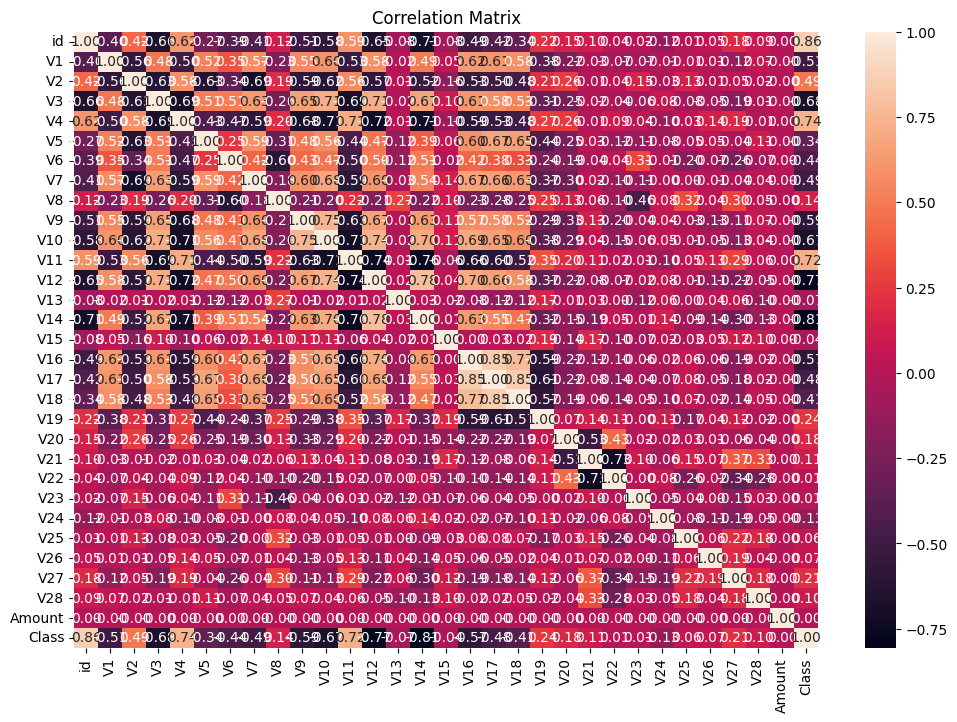

              id        V1        V2        V3        V4        V5        V6  \
id      1.000000 -0.395741  0.424267 -0.663655  0.617554 -0.268445 -0.387916   
V1     -0.395741  1.000000 -0.561184  0.484499 -0.498963  0.517462  0.354728   
V2      0.424267 -0.561184  1.000000 -0.627810  0.579638 -0.631669 -0.341040   
V3     -0.663655  0.484499 -0.627810  1.000000 -0.687726  0.510351  0.508974   
V4      0.617554 -0.498963  0.579638 -0.687726  1.000000 -0.429243 -0.474403   
V5     -0.268445  0.517462 -0.631669  0.510351 -0.429243  1.000000  0.245187   
V6     -0.387916  0.354728 -0.341040  0.508974 -0.474403  0.245187  1.000000   
V7     -0.414288  0.573381 -0.694022  0.634336 -0.588648  0.586828  0.418703   
V8      0.121282 -0.226757  0.191321 -0.263018  0.199013 -0.314975 -0.604491   
V9     -0.508427  0.548973 -0.585095  0.648615 -0.676648  0.479614  0.432241   
V10    -0.578014  0.599108 -0.621798  0.707676 -0.712839  0.563874  0.471000   
V11     0.589321 -0.525797  0.558863 -0.

In [15]:
# Check for multi-collinearity
correlation_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f")
plt.title('Correlation Matrix')
plt.show()
print(correlation_matrix)

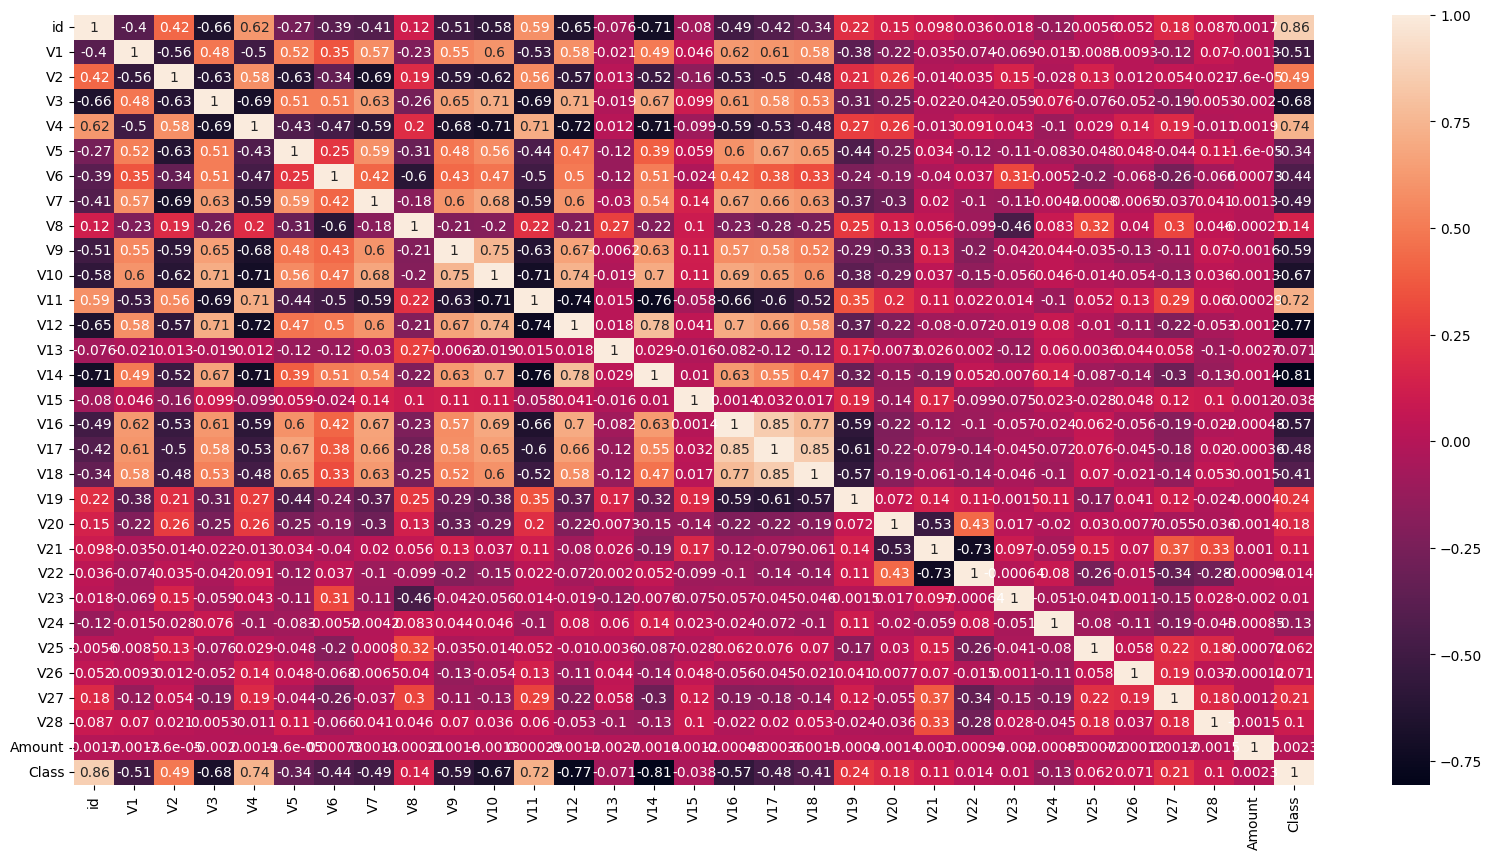

In [16]:
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [17]:
df.describe()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,568630.000000,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,...,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,568630.000000,568630.0
mean,284314.500000,-5.638058e-17,-1.319545e-16,-3.518788e-17,-2.879008e-17,7.997245e-18,-3.958636e-17,-3.198898e-17,2.109273e-17,3.998623e-17,...,4.758361e-17,3.948640e-18,6.194741e-18,-2.799036e-18,-3.178905e-17,-7.497417e-18,-3.598760e-17,2.609101e-17,12041.957635,0.5
std,164149.486121,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,...,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,6919.644449,0.5
min,0.000000,-3.495584e+00,-4.996657e+01,-3.183760e+00,-4.951222e+00,-9.952786e+00,-2.111111e+01,-4.351839e+00,-1.075634e+01,-3.751919e+00,...,-1.938252e+01,-7.734798e+00,-3.029545e+01,-4.067968e+00,-1.361263e+01,-8.226969e+00,-1.049863e+01,-3.903524e+01,50.010000,0.0
25%,142157.250000,-5.652859e-01,-4.866777e-01,-6.492987e-01,-6.560203e-01,-2.934955e-01,-4.458712e-01,-2.835329e-01,-1.922572e-01,-5.687446e-01,...,-1.664408e-01,-4.904892e-01,-2.376289e-01,-6.515801e-01,-5.541485e-01,-6.318948e-01,-3.049607e-01,-2.318783e-01,6054.892500,0.0
50%,284314.500000,-9.363846e-02,-1.358939e-01,3.528579e-04,-7.376152e-02,8.108788e-02,7.871758e-02,2.333659e-01,-1.145242e-01,9.252647e-02,...,-3.743065e-02,-2.732881e-02,-5.968903e-02,1.590123e-02,-8.193162e-03,-1.189208e-02,-1.729111e-01,-1.392973e-02,12030.150000,0.5
75%,426471.750000,8.326582e-01,3.435552e-01,6.285380e-01,7.070047e-01,4.397368e-01,4.977881e-01,5.259548e-01,4.729905e-02,5.592621e-01,...,1.479787e-01,4.638817e-01,1.557153e-01,7.007374e-01,5.500147e-01,6.728879e-01,3.340230e-01,4.095903e-01,18036.330000,1.0
max,568629.000000,2.229046e+00,4.361865e+00,1.412583e+01,3.201536e+00,4.271689e+01,2.616840e+01,2.178730e+02,5.958040e+00,2.027006e+01,...,8.087080e+00,1.263251e+01,3.170763e+01,1.296564e+01,1.462151e+01,5.623285e+00,1.132311e+02,7.725594e+01,24039.930000,1.0


In [18]:
df.corr()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
id,1.000000,-0.395741,0.424267,-0.663655,0.617554,-0.268445,-0.387916,-0.414288,0.121282,-0.508427,...,0.097948,0.036106,0.017594,-0.116685,0.005586,0.052126,0.184195,0.086822,0.001710,0.864283
V1,-0.395741,1.000000,-0.561184,0.484499,-0.498963,0.517462,0.354728,0.573381,-0.226757,0.548973,...,-0.034669,-0.073729,-0.068917,-0.014651,-0.008508,0.009281,-0.122772,0.070111,-0.001280,-0.505761
V2,0.424267,-0.561184,1.000000,-0.627810,0.579638,-0.631669,-0.341040,-0.694022,0.191321,-0.585095,...,-0.013570,0.035346,0.151906,-0.027515,0.132443,0.012219,0.053835,0.021071,-0.000076,0.491878
V3,-0.663655,0.484499,-0.627810,1.000000,-0.687726,0.510351,0.508974,0.634336,-0.263018,0.648615,...,-0.021710,-0.041970,-0.058884,0.076460,-0.076332,-0.052056,-0.190582,0.005346,-0.002001,-0.682095
V4,0.617554,-0.498963,0.579638,-0.687726,1.000000,-0.429243,-0.474403,-0.588648,0.199013,-0.676648,...,-0.013093,0.091197,0.043266,-0.102508,0.029402,0.136679,0.188036,-0.011316,0.001859,0.735981
V5,-0.268445,0.517462,-0.631669,0.510351,-0.429243,1.000000,0.245187,0.586828,-0.314975,0.479614,...,0.034147,-0.119152,-0.113919,-0.083243,-0.047845,0.047771,-0.043759,0.108422,-0.000016,-0.338639
V6,-0.387916,0.354728,-0.341040,0.508974,-0.474403,0.245187,1.000000,0.418703,-0.604491,0.432241,...,-0.040153,0.036896,0.308598,-0.005237,-0.195340,-0.067605,-0.260783,-0.065641,0.000734,-0.435088
V7,-0.414288,0.573381,-0.694022,0.634336,-0.588648,0.586828,0.418703,1.000000,-0.180986,0.601789,...,0.019627,-0.104043,-0.111177,-0.004152,0.000802,-0.006488,-0.036557,0.040732,0.001326,-0.491234
V8,0.121282,-0.226757,0.191321,-0.263018,0.199013,-0.314975,-0.604491,-0.180986,1.000000,-0.208557,...,0.056416,-0.098752,-0.463649,0.083272,0.322639,0.040448,0.298398,0.046017,-0.000208,0.144294
V9,-0.508427,0.548973,-0.585095,0.648615,-0.676648,0.479614,0.432241,0.601789,-0.208557,1.000000,...,0.131001,-0.204723,-0.042371,0.044006,-0.034885,-0.131000,-0.111842,0.069959,-0.001589,-0.585522


In [19]:
df['Class'].unique()

array([0, 1])

In [20]:
# Define Features and Target Variable

X = df.drop('Class', axis=1)
y = df['Class']

In [21]:
X.shape

(568630, 30)

In [22]:
y.shape

(568630,)

In [23]:
# Split the Dataset into Training and Testing Sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
# Standardize the Features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [25]:
#Train Decision Tree Classifier

dtree_model = DecisionTreeClassifier()
dtree_model.fit(X_train, y_train)

# Make Predictions
dt_pred = dtree_model.predict(X_test)

# Model Evaluation
#confusion_matrix=confusion_matrix(y_test, dt_pred)
print(f"Confusion Matrix: {confusion_matrix(y_test, dt_pred)}")
#classification_report=classification_report(y_test, dt_pred)
print(f"Classification Report: {classification_report(y_test, dt_pred)}")
#accuracy_score=accuracy_score(y_test, dt_pred)
print(f"Accuracy Score: {accuracy_score(y_test, dt_pred)}")

Confusion Matrix: [[56713    37]
 [   30 56946]]
Classification Report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56750
           1       1.00      1.00      1.00     56976

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726

Accuracy Score: 0.9994108647099168


In [26]:
# Train the Random Forest Classifier

rfc_model = RandomForestClassifier(n_estimators=100, random_state=42)
rfc_model.fit(X_train, y_train)

# Make Predictions
rfc_pred = rfc_model.predict(X_test)

# Model Evaluation

#cm_rfc=confusion_matrix(y_test, rfc_pred)
print(f"Confusion Matrix: {confusion_matrix(y_test, rfc_pred)}")
#cr_rfc=classification_report(y_test, rfc_pred)
print(f"Classification Report: {classification_report(y_test, rfc_pred)}")
#acc_rfc=accuracy_score(y_test, rfc_pred)
print(f"Accuracy Score: {accuracy_score(y_test, rfc_pred)}")

Confusion Matrix: [[56744     6]
 [   24 56952]]
Classification Report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56750
           1       1.00      1.00      1.00     56976

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726

Accuracy Score: 0.9997362080790673


In [27]:
# Train SVM Model
svm_model = SVC()
svm_model.fit(X_train, y_train)

# Make Prediction
svm_pred = svm_model.predict(X_test)

# Model Evaluation
#cm_svm=confusion_matrix(y_test, svm_pred)
print(f"Confusion Matrix: {confusion_matrix(y_test, svm_pred)}")
#cr_svm=classification_report(y_test, svm_pred)
print(f"Classification Report: {classification_report(y_test, svm_pred)}")
#cc_svm=accuracy_score(y_test, svm_pred)
print(f"Accuuracy Score: {accuracy_score(y_test, svm_pred)}")

Confusion Matrix: [[56734    16]
 [   21 56955]]
Classification Report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56750
           1       1.00      1.00      1.00     56976

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726

Accuuracy Score: 0.9996746566308495


In [28]:
# Train Logistic Regression Classifier

lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

# Make Predictions
lr_pred = lr_model.predict(X_test)

# Model Evaluation
#lr_cm=confusion_matrix(y_test, lr_pred)
print(f"Confusion Matrix: {confusion_matrix(y_test, lr_pred)}")
#lr_cr=classification_report(y_test, lr_pred)
print(f"Classification Report: {classification_report(y_test, lr_pred)}")
#lr_acc=accuracy_score(y_test, lr_pred)
print(f"Accuuracy Score: {accuracy_score(y_test, lr_pred)}")

Confusion Matrix: [[56689    61]
 [  121 56855]]
Classification Report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56750
           1       1.00      1.00      1.00     56976

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726

Accuuracy Score: 0.9983996623463413


In [ ]:
# Train KNeighbors Classifier
k_values = range(1,40)
score=[]

for k in k_values:
  knn_model = KNeighborsClassifier(n_neighbors=k)
  knn_model.fit(X_train, y_train)
  knn_model_pred = knn_model.predict(X_test)
  score.append(accuracy_score(y_test, knn_model_pred))


# Plot accuracy vs k
plt.plot(k_values, score, color='blue',marker='o',linestyle='--',markerfacecolor='red',markersize=10)
plt.xlabel("Value of K")
plt.ylabel("Accuracy Score")
plt.title("Choosing Optimal K for KNN")
plt.show()


best_k = k_values[score.index(max(score))]
print("Best K: ", best_k)

print(f"With K={best_k}")
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train, y_train)

# Make Prediction
knn_model_pred = knn_model.predict(X_test)

# Model Evaluation
# Evaluate the Model
print("Confusion Matrix:")
print(confusion_matrix(y_test, knn_model_pred))
print("\nClassification Report:")
print(classification_report(y_test, knn_model_pred))
print("\nAccuraccy Score:")
print(accuracy_score(y_test, knn_model_pred))

# Done